313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step
Best Random Search Config: ([128, 64], 'tanh', 0.0) with Accuracy: 0.9744
Random search results saved successfully.
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step


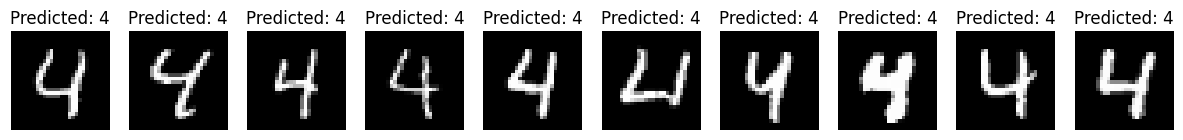

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten images for shallow networks
x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

# Function to create a shallow neural network model
def create_shallow_model(input_size, hidden_units, activation, dropout_rate, output_size):
    model = models.Sequential()
    model.add(layers.InputLayer(shape=(input_size,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation=activation))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(output_size, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ## Function to compute FLOPs (Updated to work with TF 2.x)
def compute_flops(model):
    """
    Compute FLOPs for a given TensorFlow model.
    """
    # Convert the model to a concrete function
    concrete_func = tf.function(model).get_concrete_function(tf.TensorSpec([1] + list(model.input_shape[1:]), tf.float32))

    # Freeze the model (convert variables to constants)
    frozen_func = convert_variables_to_constants_v2(concrete_func)
    frozen_graph = frozen_func.graph

    # Use TensorFlow profiler to compute FLOPs
    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

    # Compute FLOPs from the frozen graph
    flops = tf.compat.v1.profiler.profile(graph=frozen_graph, run_meta=run_meta, options=opts)

    return flops.total_float_ops if flops else 0

# Random Search Implementation
hidden_units_grid = [[32], [64], [128], [64, 32], [128, 64]]
activation_grid = ["relu", "sigmoid", "tanh"]
dropout_grid = [0.0, 0.2, 0.5]

num_trials = 10  # Number of random trials
best_acc = 0
best_model = None
best_config = None
results = []

for _ in range(num_trials):
    hidden_units = random.choice(hidden_units_grid)
    activation = random.choice(activation_grid)
    dropout = random.choice(dropout_grid)

    model = create_shallow_model(input_size=784, hidden_units=hidden_units, activation=activation,
                                 dropout_rate=dropout, output_size=10)
    
    start_time = time.time()
    history = model.fit(x_train_flat, y_train, epochs=5, verbose=0, validation_data=(x_test_flat, y_test))
    end_time = time.time()

    y_pred = model.predict(x_test_flat)
    y_pred_classes = np.argmax(y_pred, axis=1)

    classification_metrics = classification_report(y_test, y_pred_classes, output_dict=True)
    acc = accuracy_score(y_test, y_pred_classes)
    final_loss = history.history['val_loss'][-1]
    precision = classification_metrics['weighted avg']['precision']
    recall = classification_metrics['weighted avg']['recall']
    f1_score = classification_metrics['weighted avg']['f1-score']
    training_time = end_time - start_time
    num_params = model.count_params()
    num_flops = compute_flops(model)

    results.append({
        'Configuration': f"{hidden_units}, {activation}, {dropout}",
        'Accuracy': acc,
        'Loss': final_loss,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score,
        'Training Time (s)': training_time,
        'Num Params': num_params,
        'Num FLOPs': num_flops
    })

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_config = (hidden_units, activation, dropout)

print(f"Best Random Search Config: {best_config} with Accuracy: {best_acc}")

# Save results
df_results = pd.DataFrame(results)
df_results.to_excel('random_search_results.xlsx', index=False)

print("Random search results saved successfully.")


target_digit = int(input("Enter a number (0-9) to search for detected images: "))
def search_and_display_images(model, target_digit):
    y_pred = model.predict(x_test_flat)
    predicted_labels = np.argmax(y_pred, axis=1)

    indices = np.where(predicted_labels == target_digit)[0][:10]  # Get first 10 matches

    if len(indices) == 0:
        print(f"No images found for predicted digit {target_digit}.")
        return

    fig, axes = plt.subplots(1, len(indices), figsize=(15, 5))
    for i, idx in enumerate(indices):
        axes[i].imshow(x_test[idx], cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Predicted: {predicted_labels[idx]}")

    plt.show()
    plt.close(fig)  
    
search_and_display_images(best_model, target_digit)